<a href="https://colab.research.google.com/github/facundomatoff/DOC26_IAM_TP/blob/main/Doc26_IAM_Trabajo_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Sistema de Detección de Bebidas en Heladeras Exhibidoras mediante YOLOv8**

**Doctorado en Informática**

**Materia:** Introducción al Aprendizaje de Máquinas  
**Entorno de entrenamiento:** Google Colab (GPU Tesla T4)  
**Framework:** Ultralytics YOLOv8 · PyTorch 2.11.0 · CUDA 12.8

*Importante: El siguiente informe fue generado con asistencia de Inteligencia Artificial.*

## 1. Introducción

### 1.1 Descripción del Problema

Un cliente propietario de heladeras exhibidoras comerciales requería un sistema automatizado para verificar que los productos almacenados en sus heladeras correspondieran a su propio catálogo de bebidas, y no a productos de la competencia introducidos por terceros sin autorización.

Para abordar este problema, se planificó la instalación de dos cámaras inteligentes por heladera: una ubicada en la parte superior y otra en el lateral. Cada vez que la puerta se abría, las cámaras capturaban un video corto con el objetivo de detectar qué productos eran extraídos. Estos videos eran luego descompuestos en frames (imágenes individuales), de los cuales solo una fracción contenía información útil para el análisis.

### 1.2 Desafíos del Entorno

El entorno presentó múltiples desafíos técnicos:

- **Reflejos en el vidrio:** Al abrir la puerta, el vidrio refleja el contenido interior y objetos externos, generando detecciones falsas.
- **Oclusión parcial:** La forma en que los usuarios sostienen las botellas frecuentemente oculta elementos identificadores clave (etiquetas, color de tapa, forma del envase).
- **Alta tasa de frames vacíos:** La descomposición de video generaba una cantidad muy elevada de imágenes sin objetos de interés, lo que requirió una etapa de pre-filtrado.
- **Ambigüedad visual entre productos similares:** Botellas de 500cc de distintas marcas (especialmente Pepsi y Coca-Cola, ambas con líquido oscuro) son visualmente indistinguibles en muchos frames.
- **Ausencia de dataset preexistente:** No existía ningún dataset público adecuado para este escenario específico, por lo que fue necesario construir uno desde cero.
- **Cambios en el packaging:** Durante el desarrollo, una marca de agua mineral modificó el diseño de su botella, afectando la capacidad de clasificación del modelo ya entrenado.

---

## 2. Descripción del Algoritmo: YOLOv8 Nano

### 2.1 Selección del Modelo

Se seleccionó **YOLOv8** (You Only Look Once, versión 8) en su variante **Nano (YOLOv8n)** como arquitectura de detección de objetos. YOLO es una familia de detectores de objetos en tiempo real basada en redes neuronales convolucionales profundas que procesan la imagen completa en un único pase (de ahí el nombre "You Only Look Once"), lo que le confiere velocidades de inferencia muy superiores a arquitecturas de dos etapas como Faster R-CNN [1].

La elección de YOLOv8 sobre otras alternativas se fundamenta en los siguientes criterios:

- **Velocidad de inferencia:** YOLOv8n alcanza inferencias de 3–4 ms por imagen en GPU, compatible con el procesamiento en tiempo real requerido por las cámaras inteligentes [2].
- **Eficiencia computacional:** Con solo 3.2 millones de parámetros y 8.1 GFLOPs, el modelo puede ser desplegado directamente en el hardware embebido de las cámaras.
- **Transfer Learning:** Los pesos preentrenados en COCO (80 clases, incluyendo `bottle` y `cup`) proporcionan una base sólida para el fine-tuning sobre el dataset propio [3].
- **Ecosistema Ultralytics:** La biblioteca Ultralytics facilita el entrenamiento, validación, exportación y despliegue en entornos edge (TensorRT, ONNX, CoreML) [4].

**¿Por qué no otros modelos?**

- **Faster R-CNN / Mask R-CNN:** Arquitecturas de dos etapas con mayor precisión pero latencia incompatible con el procesamiento en tiempo real en hardware embebido.
- **SSD (Single Shot Detector):** Menos preciso que YOLOv8 en objetos pequeños y parcialmente ocluidos, frecuentes en este escenario.
- **EfficientDet:** Buen balance precisión/velocidad, pero el ecosistema de herramientas y la comunidad de soporte son menos maduros que Ultralytics/YOLO para despliegue en cámaras inteligentes.


### 2.2 Arquitectura del Modelo

El modelo empleado corresponde al punto de partida `yolov8n.pt`, con los siguientes parámetros arquitecturales:

| Componente | Detalle |
|---|---|
| Versión | YOLOv8 Nano |
| Capas (fusionadas) | 73 |
| Parámetros totales | 3,006,623 (~3.0M) |
| GFLOPs | 8.1 |
| Neuronas de entrada | Tensor de forma `[batch, 3, 320, 320]` (imagen RGB 320×320) |
| Salida | Tensores en 3 escalas: `[batch, 4+nc, H/8, W/8]`, `[batch, 4+nc, H/16, W/16]`, `[batch, 4+nc, H/32, W/32]` con `nc=5` clases |

> **Nota sobre `imgsz=320`:** Las imágenes del dataset son de 300×300 px. YOLOv8 requiere que el tamaño de entrada sea múltiplo de 32, por lo que se utilizó 320 (el múltiplo de 32 más cercano). El modelo ajusta internamente las imágenes a esta resolución mediante padding proporcional.

### 2.3 Hiperparámetros de Entrenamiento

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `epochs` | 50 | Suficiente para convergencia en dataset mediano sin sobreajuste |
| `imgsz` | 320 | Múltiplo de 32 más cercano al tamaño original (300px) |
| `batch` | Auto (Ultralytics) | Optimizado según VRAM disponible (14,913 MiB Tesla T4) |
| `optimizer` | AdamW (default) | Convergencia más estable que SGD en datasets pequeños |
| `lr0` | 0.01 (default) | Learning rate inicial con warm-up lineal |
| `lrf` | 0.01 (default) | Factor de decaimiento final (cosine annealing) |
| `momentum` | 0.937 (default) | Parámetro momentum para SGD/AdamW |
| `pretrained` | `yolov8n.pt` (COCO) | Transfer learning desde 80 clases COCO |
| `data` | `data.yaml` | Configuración de clases y rutas del dataset |

**Función de pérdida:** YOLOv8 utiliza una pérdida compuesta por tres términos:
- **`box_loss` (CIoU Loss):** Penaliza el error en la localización de las cajas delimitadoras, considerando solapamiento, distancia de centros y relación de aspecto.
- **`cls_loss` (Binary Cross-Entropy):** Penaliza errores de clasificación por clase (clasificación multi-label).
- **`dfl_loss` (Distribution Focal Loss):** Modela la distribución de probabilidad sobre la posición de cada borde de la caja, mejorando la precisión en objetos con bordes ambiguos [5].
---

## 3. Descripción de la Solución Implementada

### 3.1 Proceso General y Herramientas (scripts) utilizados

La solución implementada siguió el siguiente flujo de trabajo, junto con un conjunto de scripts Python que permitieron generar el dataset para el re-entrenamiento:

| Paso | Acción | Herramienta / Script | Descripción de la Herramienta | Resultado |
|:----:|--------|----------------------|-------------------------------|-----------|
| 1 | Captura de video | *(Sin script — cámaras inteligentes)* | Las cámaras ubicadas en la parte superior y lateral de la heladera graban automáticamente un video corto cada vez que se abre la puerta. | Videos cortos en formato GIF/video por evento de apertura de puerta. |
| 2 | Descomposición en frames | `extract_frames.py` | Recorre la lista de GIFs y los separa en frames individuales (imágenes PNG), generando una carpeta de frames por cada GIF procesado. | Carpetas individuales con imágenes PNG extraídas de cada video/GIF. |
| 3 | Pre-filtrado con YOLOv8 preentrenado (COCO) | `identity_bottles.py` | Recorre los frames PNG dentro de cada carpeta y detecta botellas o latas usando YOLOv8. Genera archivos de etiquetas `.txt` con las coordenadas del objeto detectado, para su posterior validación manual. | Frames candidatos con archivos de etiquetas `.txt` asociados listos para revisión. |
| 3 | Pre-filtrado con YOLOv8 preentrenado (COCO) | `isolate_empty_labels.py` | Recorre las imágenes PNG y elimina las etiquetas vacías (sin objetos detectados), limpiando el conjunto de datos. También cuenta la cantidad de imágenes y muestra estadísticas de distribución de clases. | Reducción de ~40–50% de frames vacíos. Estadísticas de distribución del dataset resultante. |
| 3 | Pre-filtrado con YOLOv8 preentrenado (COCO) | `train_dataset_generator.py` | Toma los frames candidatos al reentrenamiento y los organiza en la estructura de carpetas requerida por YOLO (`images/` y `labels/`). | Dataset organizado en la estructura de directorios compatible con YOLOv8. |
| 3 | Pre-filtrado con YOLOv8 preentrenado (COCO) | `analyze_dataset.py` | Extrae un reporte con la cantidad total de imágenes reconocidas sobre el conjunto completo de frames procesados. | Reporte con totales y distribución de imágenes candidatas por clase. |
| 4 | Etiquetado manual asistido | `desktop.py` | Aplicación Python de escritorio que permite iterar imagen por imagen, revisar el frame detectado por YOLO y reclasificar las etiquetas según las nuevas clases requeridas por el cliente (`pepsi_bottle`, `water_bottle`, `generic_bottle`, `aluminum_can`, `unknown`). Lee el archivo `data.yaml` para obtener la lista de nuevas etiquetas. | Dataset re-etiquetado con clases propias del cliente. Reducción adicional de ~10% de imágenes erróneas mediante revisión humana. |
| 5 | Construcción del dataset (train / val / test) | `generate_split_lists.py` | Genera tres archivos `.txt` (`train.txt`, `val.txt`, `test.txt`) con las rutas completas de las imágenes, distribuidas y mezcladas aleatoriamente entre los tres conjuntos. | Tres listas de rutas de imágenes listas para ser referenciadas en `data.yaml` durante el entrenamiento. |
| 6 | Fine-tuning YOLOv8n | *(Google Colab — Notebook)* | Entrenamiento del modelo `yolov8n.pt` mediante la biblioteca Ultralytics sobre GPU Tesla T4, usando `data.yaml` como configuración de clases y rutas, con `epochs=50` e `imgsz=320`. | Archivo de pesos reentrenados `best.pt` con las 5 clases del cliente. |
| 7 | Validación y testing del modelo | *(Ultralytics `model.val()`)* | Evaluación del modelo sobre el conjunto de test (303 imágenes, 471 instancias) para obtener métricas de precisión, recall, mAP50 y mAP50-95 por clase. | mAP50 global: **0.908** · mAP50-95: **0.780** · Velocidad: ~3.4 ms/imagen. |
| 8 | Exportación para despliegue | *(Ultralytics `model.export()`)* | Exportación del modelo reentrenado a un formato compatible con el hardware embebido de las cámaras inteligentes (ONNX / TensorRT según el dispositivo). | Archivo de modelo optimizado listo para despliegue en cámaras inteligentes. |

#### 3.1.1 Resultados del Paso 2 y 3: Extracciones de Frames y fildrado de los mismos

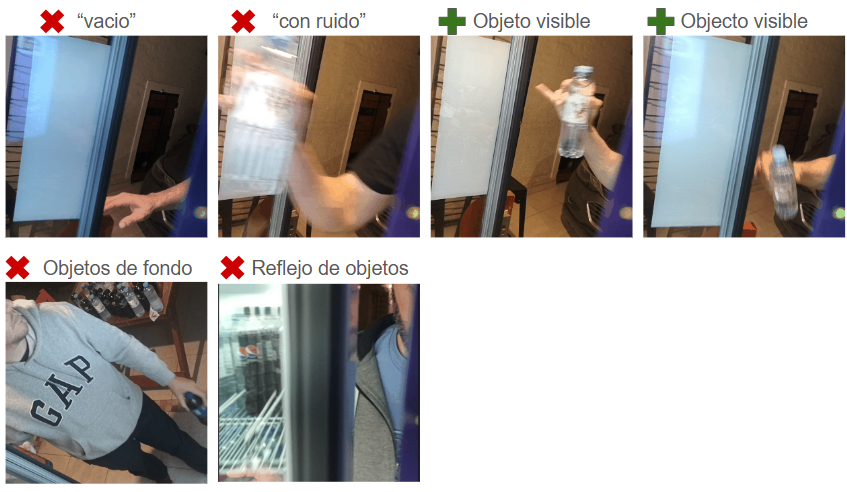

#### 3.1.2 Resultado del Paso 4: Reclasificationes o etiquetado con Clases definidas por el Cliente utilizando Aplicaciones a medida

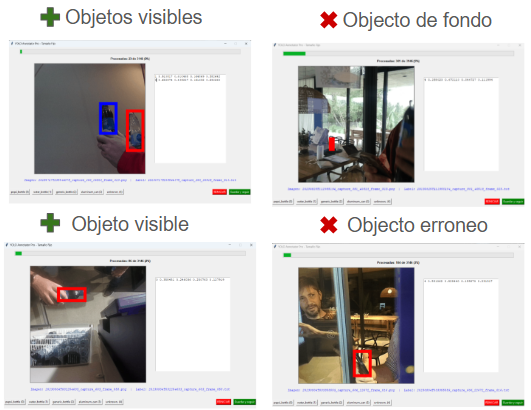

### 3.2 Dataset para el Re-entrenamiento

Como se mencionó anteriormente, dado que no existía ningún dataset público adecuado para este escenario, fue necesario construir uno desde cero mediante la generación de videos de prueba en condiciones controladas que simulaban el uso real de las heladeras.

**Distribución del dataset de entrenamiento:**

| ID | Clase | Descripción | Instancias (train) |
|---|---|---|---|
| 0 | `pepsi_bottle` |  Botella con líquido oscuro (Pepsi y Coca-Cola indistinguibles) | 504 |
| 1 | `water_bottle` | Botella de agua mineral | 1,177 |
| 2 | `generic_bottle` | Otras botellas no identificadas por marca | 168 |
| 3 | `aluminum_can` | Latas de aluminio | 38 |
| 4 | `unknown` | Objetos ambiguos: reflejos, elementos lejanos, objetos del usuario | 1,293 |
||| **Total** | **3,180** |

El desbalance entre clases refleja la distribución real del escenario: la clase `unknown` predomina porque los reflejos, objetos lejanos y elementos del usuario (teléfonos, manos) son frecuentes en los videos capturados. La clase `aluminum_can` es la menos representada, lo que impacta directamente en su rendimiento.

### 3.3 Problemas Encontrados y Decisiones Tomadas

**Problema 1: Indistinguibilidad Pepsi/Coca-Cola**  
Ambas bebidas presentan botellas de 500cc con líquido oscuro. El color de la tapa, la etiqueta y la forma del envase resultan irreconocibles cuando el usuario sostiene la botella en movimiento. **Decisión:** Unificar ambas bajo la clase `pepsi_bottle` y delegar la distinción final a validación humana posterior.

**Problema 2: Cambio de packaging de agua mineral**  
Durante el proyecto, la marca de agua mineral modificó el diseño de su botella, provocando errores de clasificación en el modelo ya entrenado. **Decisión:** Este tipo de cambio requiere la incorporación de nuevas imágenes con el nuevo diseño y un ciclo adicional de fine-tuning, evidenciando la necesidad de mantenimiento continuo del modelo.

**Problema 3: Alta tasa de frames vacíos**  
La descomposición de video genera miles de frames sin objetos relevantes. **Decisión:** Pre-procesar todos los frames con YOLOv8 preentrenado en COCO para retener solo aquellos donde se detecta al menos un objeto de la categoría `bottle` o `cup`, reduciendo el volumen en un 40–50%.

**Problema 4: Reflejos y objetos de fondo**  
Productos visibles a través del vidrio de la puerta y reflejos generaban detecciones falsas. **Decisión:** Crear la clase `unknown` para capturar estos casos ambiguos, entrenando explícitamente al modelo para reconocer situaciones de incertidumbre en lugar de forzar una clasificación incorrecta.

---

## 4. Simulaciones Realizadas y Resultados Obtenidos

### 4.1 Evolución del Entrenamiento (50 épocas)

El modelo fue entrenado durante 50 épocas sobre Google Colab utilizando la GPU Tesla T4 (14,913 MiB VRAM). El tiempo total de entrenamiento fue de aproximadamente **1,660 segundos (~27.7 minutos)**, con un promedio de ~33 segundos por época.

#### Curvas de Pérdida

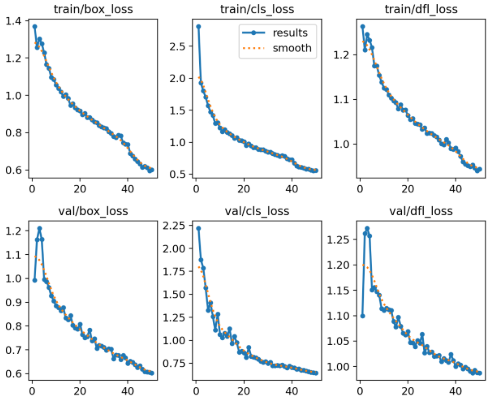

Las curvas de pérdida tanto de entrenamiento como de validación muestran una convergencia sostenida y sin divergencia, lo que indica ausencia de sobreajuste significativo:

| Métrica | Época 1 | Época 25 | Época 50 |
|---|---|---|---|
| `train/box_loss` | 1.370 | 0.868 | 0.601 |
| `train/cls_loss` | 2.812 | 0.915 | 0.557 |
| `train/dfl_loss` | 1.264 | 1.044 | 0.944 |
| `val/box_loss` | 0.992 | 0.738 | 0.603 |
| `val/cls_loss` | 2.219 | 0.810 | 0.646 |
| `val/dfl_loss` | 1.100 | 1.046 | 0.988 |

La convergencia paralela entre las pérdidas de entrenamiento y validación confirma que el modelo generaliza correctamente, sin memorizar el conjunto de entrenamiento.

#### Evolución de Métricas de Rendimiento

| Métrica | Época 1 | Época 25 | Época 50 |
|---|---|---|---|
| Precisión | 0.443 | 0.812 | 0.870 |
| Recall | 0.396 | 0.689 | 0.800 |
| mAP50 | 0.409 | 0.825 | 0.899 |
| mAP50-95 | 0.282 | 0.642 | 0.730 |

Las métricas muestran una mejora continua y pronunciada durante las primeras 30 épocas, seguida de una estabilización hacia las épocas 40–50, señal clara de que el modelo alcanzó su capacidad máxima de aprendizaje con los datos disponibles.

### 4.2 Resultados de Validación Final

Los resultados obtenidos al evaluar el modelo sobre el conjunto de validación (303 imágenes, 471 instancias) son los siguientes:

| Clase | Imágenes | Instancias | Precisión | Recall | mAP50 | mAP50-95 |
|---|---|---|---|---|---|---|
| **all** | 303 | 471 | **0.843** | **0.840** | **0.908** | **0.780** |
| `pepsi_bottle` | 61 | 65 | 0.905 | 0.908 | 0.933 | 0.804 |
| `water_bottle` | 139 | 166 | 0.899 | 0.912 | 0.928 | 0.777 |
| `generic_bottle` | 23 | 24 | 0.811 | 0.716 | 0.886 | 0.786 |
| `aluminum_can` | 6 | 6 | 0.767 | 0.833 | 0.915 | 0.804 |
| `unknown` | 89 | 210 | 0.833 | 0.831 | 0.878 | 0.728 |

**Velocidad de inferencia:** 1.1 ms (preproceso) + 3.4 ms (inferencia) + 2.1 ms (postproceso) = **~6.6 ms por imagen (~150 FPS)**.

### 4.3 Análisis de la Matriz de Confusión

La matriz de confusión normalizada revela los siguientes patrones de comportamiento del modelo:

- **`pepsi_bottle` (0.93):** Clasificación excelente. El 12% de los fondos de la clase `background` son predichos como `pepsi_bottle`, posiblemente por objetos con colores similares al packaging.
- **`water_bottle` (0.90):** Alto rendimiento. Se observa confusión con `aluminum_can` (33% de las latas son predichas como `water_bottle`), lo cual es esperable dado el bajo número de instancias de latas en el dataset.
- **`generic_bottle` (0.86):** Buen rendimiento considerando la heterogeneidad visual de esta clase.
- **`aluminum_can` (0.50):** El rendimiento más bajo, directamente relacionado con el escaso número de instancias de entrenamiento (solo 38 en el dataset y 6 en validación). El 33% es confundido con `water_bottle`.
- **`unknown` (0.92):** Muy alta tasa de acierto para una clase intrínsecamente ambigua. El 57% de los fondos (`background`) son clasificados como `unknown`, lo cual es el comportamiento esperado y deseado: el modelo prefiere asignar `unknown` antes que forzar una clase incorrecta.
### 4.4 Análisis del Dataset (Labels)

El gráfico de distribución de labels muestra:
- Las cajas delimitadoras se concentran mayoritariamente en la zona central-derecha de la imagen, lo cual es consistente con la posición de los objetos al ser extraídos de la heladera.
- La distribución de tamaños de caja (ancho ~0.1–0.2, alto ~0.15–0.25) indica que los objetos ocupan una fracción moderada del frame, compatible con la distancia de captura de las cámaras.
- La variabilidad en posición y tamaño es adecuada para el entrenamiento de un detector robusto.
### 4.5 Interpretación de las Gráficas de Resultados

Las gráficas de `results.png` confirman lo descrito en los logs:

- **Pérdidas de entrenamiento:** Descenso monotónico y suave en las tres componentes (`box_loss`, `cls_loss`, `dfl_loss`), sin oscilaciones abruptas post-época 10.
- **Pérdidas de validación:** Descenso paralelo al entrenamiento, sin divergencia, confirmando la ausencia de sobreajuste.
- **Precisión:** Estabilización en torno a 0.87–0.90 desde la época 35.
- **Recall:** Crecimiento sostenido hasta ~0.80, con ligera variabilidad residual en las épocas finales.
- **mAP50:** Supera 0.85 desde la época 30, alcanzando 0.899 al final.
- **mAP50-95:** Crecimiento más gradual, estabilizándose en ~0.73, lo que indica alta calidad en la localización de cajas.
---

In [ ]:
import os

# Monta el GDrive personal para persistir el nuevo archivo de pesos del entrenamiento
from google.colab import drive
drive.mount('/content/drive')

ROOT_DIR = os.path.abspath("drive/MyDrive/DOC26_IAM_TP")

MAIN_PATH = os.path.join(ROOT_DIR, "DOC26_IAM_TP-main")
DATA_SET_SPLIT_PATH = os.path.join(ROOT_DIR, "DOC26_IAM_TP-main/dataset_split")
RUNS_PATH = os.path.join(ROOT_DIR, "DOC26_IAM_TP-main/runs")

if not os.path.exists(ROOT_DIR):
  print("Crear carpeta para el proyecto")
  os.mkdir(ROOT_DIR)

!wget "https://github.com/facundomatoff/DOC26_IAM_TP/archive/refs/heads/main.zip" -P {ROOT_DIR}
!unzip -qq {os.path.join(ROOT_DIR, "main.zip")} "DOC26_IAM_TP-main/*" -d {ROOT_DIR}
#!unzip -qq {os.path.join(ROOT_DIR, "main.zip")} "DOC26_IAM_TP-main/dataset/*" -d {ROOT_DIR}
#!unzip -qq {os.path.join(ROOT_DIR, "main.zip")} "DOC26_IAM_TP-main/dataset_split/*" -d {ROOT_DIR}
!rm {os.path.join(ROOT_DIR, "main.zip")}


Mounted at /content/drive
Crear carpeta para el proyecto
--2026-07-14 11:34:55--  https://github.com/facundomatoff/DOC26_IAM_TP/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/facundomatoff/DOC26_IAM_TP/zip/refs/heads/main [following]
--2026-07-14 11:34:55--  https://codeload.github.com/facundomatoff/DOC26_IAM_TP/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.116.9
Connecting to codeload.github.com (codeload.github.com)|140.82.116.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘/content/drive/MyDrive/DOC26_IAM_TP/main.zip’

main.zip                [          <=>       ] 304.11M  16.0MB/s    in 16s     

2026-07-14 11:35:11 (19.6 MB/s) - ‘/content/drive/MyDrive/DOC26_IAM_TP/main.zip’ saved [31888531

In [ ]:
# 1. Clona el repositorio de Github
#!git clone https://github.com/facundomatoff/DOC26_IAM_TP.git

# 2. Selecciona la carpeta raiz del proyecto
#%cd /content/DOC26_IAM_TP

In [ ]:
# Instala las dependencias y librerias necesarias
!pip install ultralytics

# 3. Lanzar el entrenamiento de un modelo de YOLO
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Se utiliza el modelo YOLO en su version '8' y un tamaño 'Nano'
# Esta la versión más ligera y rápida de YOLO, lo que te permite entrenar en pocos minutos sin agotar los límites de la
# GPU gratuita de Colab.
# El parámetro 'YOLOv8n.pt' indica tres partes clave que definen su comportamiento
# YOLOv8:       Indica la octava versión de la arquitectura YOLO
# n (Nano):     Representa el tamaño del modelo, en este caso el mas pequeño de la familia, con 3.2 millones de parámetros.
# pt (PyTorch): Es la extensión de archivo que indica que contiene los pesos preentrenados del modelo en el dataset COCO
#               (un conjunto de 80 objetos cotidianos).

model = YOLO('yolov8n.pt')

# Parámetros
# data:   Se indica la 'ruta' al archivo de configuración en donde se establecen las clases a reconocer, y las imágenes de
#         entrenamiento (train), validación (val) y testing (test)
# epochs: Indica la cantidad de épocas de entranamiento. En este caso se selecciona un valor de 50
# imgsz:  Esta variable indica el tamaño de las imágenes de entrada (ancho y alto).
#         Siendo que las imágenes para entrenamiento son de 300 x 300 píxeles, se utilizará el valor 320 para la variable,
#         ya que las arquitecturas de YOLO operan dividiendo las imágenes en una cuadrícula y 'imgsz' siempre se ajusta
#         internamente al múltiplo de 32 más cercano

# 2. Selecciona la carpeta raiz del proyecto
%cd /content/drive/MyDrive/DOC26_IAM_TP/DOC26_IAM_TP-main/

model.train(data='data.yaml',
            epochs=50,
            imgsz=320)

# 2. Definir la configuración en un diccionario
#data_config = {
#    'path': MAIN_PATH,
#    'train': os.path.join(DATA_SET_SPLIT_PATH, 'train.txt'),
#    'val': os.path.join(DATA_SET_SPLIT_PATH, 'val.txt'),
#    'test': os.path.join(DATA_SET_SPLIT_PATH, 'test.txt'),
#    'nc': 5,
#    'names': {
#        0: 'pepsi_bottle',
#        1: 'water_bottle',
#        2: 'generic_bottle',
#        3: 'aluminum_can',
#        4: 'unknown'
#    }
#}

# 3. Entrenar pasando el diccionario directamente
#model.train(data=data_config,
#            epochs=50,
#            imgsz=320,
#            project=RUNS_PATH, # Persiste el entrenamiento en el Drive
#            name='detect_train')



/content/drive/MyDrive/DOC26_IAM_TP/DOC26_IAM_TP-main
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7af72ea75400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
model = YOLO('/content/drive/MyDrive/DOC26_IAM_TP/DOC26_IAM_TP-main/runs/detect/train/weights/best.pt')

# Ejecutar la validación sobre el conjunto de test
metrics = model.val(data='data.yaml',
                    split='test',
                    imgsz=320)

# Opcional: Imprimir métricas específicas
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 57.5±9.8 MB/s, size: 104.8 KB)
val: Scanning dataset/labels... 303 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 303/303 164.7it/s 1.8s
val: New cache created: dataset/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.8it/s 5.0s
                   all        303        471      0.843       0.84      0.908       0.78
          pepsi_bottle         61         65      0.905      0.908      0.933      0.804
          water_bottle        139        166      0.899      0.912      0.928      0.777
        generic_bottle         23         24      0.811      0.716      0.886      0.786
          aluminum_can          6          6      0.767      0.833      0.915      0.804
               unknown      

## 5. Conclusiones

El presente trabajo demostró la viabilidad de implementar un sistema de detección de bebidas en heladeras comerciales basado en YOLOv8n, logrando resultados robustos a pesar de las significativas restricciones del escenario.

**Conclusiones técnicas:**

1. **El modelo alcanzó convergencia satisfactoria en 50 épocas**, con un mAP50 global de 0.908 y mAP50-95 de 0.780. No se recomienda extender el entrenamiento sin incorporar nuevos datos, ya que las curvas de pérdida de validación ya se han aplanado.
2. **YOLOv8n demostró ser la arquitectura correcta** para este despliegue: su balance entre precisión (mAP50 > 0.90 en 3 de 5 clases) y velocidad de inferencia (~3.4 ms/imagen en GPU) lo hace compatible con el hardware embebido de las cámaras inteligentes.
3. **El desbalance de clases impacta directamente en `aluminum_can`**, que con solo 38 instancias de entrenamiento obtuvo el menor rendimiento (mAP50: 0.915 pero con solo 6 instancias de validación, lo que hace esta métrica estadísticamente poco significativa). Se recomienda ampliar el dataset para esta clase.
4. **La clase `unknown` cumple su función de "válvula de seguridad"**: con un 92% de acierto y tendencia a absorber fondos ambiguos (57% del background predicho como `unknown`), el modelo prefiere la incertidumbre antes que la clasificación incorrecta.
5. **La indistinguibilidad Pepsi/Coca-Cola es una limitación inherente al problema**, no superable mediante técnicas de visión computacional sin información adicional (ángulo de captura adicional, iluminación estructurada, o lectura de códigos QR/barras).
**Conclusiones del proceso:**

6. **La generación de datasets propios es el mayor costo del proyecto** en términos de tiempo y esfuerzo, y debe ser planificada como un proceso continuo. El cambio de packaging de agua mineral evidenció la necesidad de mecanismos de reentrenamiento periódico.
7. **El pre-filtrado con YOLOv8 preentrenado en COCO** para eliminar frames vacíos fue una decisión acertada que mejoró significativamente la calidad del dataset y redujo el esfuerzo de etiquetado manual.
8. **La solución es escalable** a nuevos productos mediante ciclos de fine-tuning adicionales, siempre que se pueda construir un conjunto representativo de imágenes para la nueva clase.
---

## 6. Referencias

[1] Redmon, J., Divvala, S., Girshick, R., & Farhadi, A. (2016). **You only look once: Unified, real-time object detection.** *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, 779–788. https://doi.org/10.1109/CVPR.2016.91

[2] Jocher, G., Chaurasia, A., & Qiu, J. (2023). **Ultralytics YOLO** (Version 8.0.0) [Software]. https://github.com/ultralytics/ultralytics

[3] Lin, T. Y., Maire, M., Belongie, S., Hays, J., Perona, P., Ramanan, D., ... & Zitnick, C. L. (2014). **Microsoft COCO: Common objects in context.** *European Conference on Computer Vision (ECCV)*, 740–755. https://doi.org/10.1007/978-3-319-10602-1_48

[4] Terven, J., Córdova-Esparza, D. M., & Romero-González, J. A. (2023). **A Comprehensive Review of YOLO Architectures in Computer Vision: From YOLOv1 to YOLOv8 and YOLO-NAS.** *Machine Learning and Knowledge Extraction*, 5(4), 1680–1716. https://doi.org/10.3390/make5040083

[5] Li, X., Wang, W., Wu, L., Chen, S., Hu, X., Li, J., ... & Yang, J. (2020). **Generalized Focal Loss: Learning Qualified and Distributed Bounding Boxes for Dense Object Detection.** *Advances in Neural Information Processing Systems (NeurIPS)*, 33, 21002–21012. https://arxiv.org/abs/2006.04388

[6] Hussain, M. (2023). **YOLO-v1 to YOLO-v8, the Rise of YOLO and Its Complementary Nature toward Digital Manufacturing and Industrial Defect Detection.** *Machines*, 11(7), 677. https://doi.org/10.3390/machines11070677

[7] Jiang, P., Ergu, D., Liu, F., Cai, Y., & Ma, B. (2022). **A Review of YOLO Algorithm Developments.** *Procedia Computer Science*, 199, 1066–1073. https://doi.org/10.1016/j.procs.2022.01.135

[8] Bochkovskiy, A., Wang, C. Y., & Liao, H. Y. M. (2020). **YOLOv4: Optimal Speed and Accuracy of Object Detection.** *arXiv preprint arXiv:2004.10934*. https://arxiv.org/abs/2004.10934